# Formation RAG -- Séance 2 : construire un RAG pas-à-pas

Dans ce notebook, nous construisons un **Naive RAG fonctionnel** sur un PDF, en explorant chaque brique du pipeline une par une et en observant **le rendu de chaque étape**.

À la fin du notebook, nous verrons comment ce code exploratoire a été **refactoré en un package Python professionnel** (`src/rag_pdf/`), réutilisable en 3 lignes.

## Le corpus

Nous utilisons le **PDF du cours théorique de la séance 1**. Effet miroir amusant : nous construisons un RAG qui répond aux questions sur le cours de RAG.

> ⚠️ **Préalable** : assurez-vous d'avoir compilé `cours_rag_theorie.tex` en PDF (deux passes `pdflatex`) et placé le PDF dans `seance2/data/pdfs/cours_rag_theorie.pdf`.

## Pipeline construit

```
 PDF ──► Loader ──► Splitter ──► Embeddings ──► Vector store
                                                      │
 Question ──► Retriever ◄────────────────────────────┘
       │
       └──► Prompt augmenté ──► LLM (Groq) ──► Réponse + sources [Page X]
```

---
## 0. Setup

On charge les variables d'environnement (`GROQ_API_KEY`) et on ajuste le `sys.path` pour pouvoir importer notre package `rag_pdf` depuis le notebook.

In [1]:
import sys
from pathlib import Path

# Le notebook est dans seance2/notebooks/, le package dans seance2/src/.
# Si `uv sync` a installé le package en editable, l'ajout de sys.path est inutile.
# On le fait par sécurité pour qu'un Restart Kernel + Run This Cell suffise.
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
src_dir = project_root / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

# Note : la config (`rag_pdf.config.settings`) charge automatiquement le .env
# depuis seance2/.env avec un chemin absolu. On vérifie quand même la clé.
import os
from dotenv import load_dotenv
load_dotenv(project_root / ".env")
assert os.getenv("GROQ_API_KEY"), "❌ GROQ_API_KEY manquante — vérifiez votre fichier .env"

print("✓ Environnement chargé")
print(f"✓ Racine projet : {project_root}")

✓ Environnement chargé
✓ Racine projet : C:\Users\User\Desktop\Developpement\Formation-RAG\seance2


---
## 1. Chargement du PDF

**Objectif** : extraire le texte du PDF tout en conservant les **numéros de page** en métadonnée. Ces numéros sont cruciaux : c'est ce qui permettra plus tard au RAG de citer ses sources, et à notre app web (séance 3) d'afficher la page exacte.

On utilise `PyMuPDFLoader` (LangChain wrapper de PyMuPDF). PyMuPDF est rapide, précis, et préserve bien la structure.

In [2]:
from langchain_community.document_loaders import PyMuPDFLoader

pdf_path = project_root / "data" / "pdfs" / "cours_rag_theorie.pdf"
assert pdf_path.exists(), f"❌ PDF introuvable : {pdf_path}\nVérifiez le chemin spécifié !!!"

loader = PyMuPDFLoader(str(pdf_path))
documents = loader.load()

print(f"✓ {len(documents)} pages chargées depuis {pdf_path.name}")
print(f"✓ Type d'un élément : {type(documents[0]).__name__}")

✓ 29 pages chargées depuis cours_rag_theorie.pdf
✓ Type d'un élément : Document


### Que contient un `Document` ?

Chaque `Document` a deux attributs :
- `page_content` : le texte de la page
- `metadata` : un dict avec au minimum `source` (chemin du PDF) et `page` (n° de page, 0-indexé chez PyMuPDF)

In [3]:
# Regardons la 5ᵉ page (index 4) — généralement le début du contenu après la table des matières.
doc = documents[4]
print("=== METADATA ===")
print(doc.metadata)
print("\n=== EXTRAIT DU CONTENU (500 premiers caractères) ===")
print(doc.page_content[:500])

=== METADATA ===
{'producer': 'pdfTeX-1.40.27', 'creator': 'LaTeX with hyperref', 'creationdate': '2026-05-20T16:23:22+00:00', 'source': 'C:\\Users\\User\\Desktop\\Developpement\\Formation-RAG\\seance2\\data\\pdfs\\cours_rag_theorie.pdf', 'file_path': 'C:\\Users\\User\\Desktop\\Developpement\\Formation-RAG\\seance2\\data\\pdfs\\cours_rag_theorie.pdf', 'total_pages': 29, 'format': 'PDF 1.5', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2026-05-20T16:23:22+00:00', 'trapped': '', 'modDate': 'D:20260520162322Z', 'creationDate': 'D:20260520162322Z', 'page': 4}

=== EXTRAIT DU CONTENU (500 premiers caractères) ===
1
Introduction et objectifs
1.1
Pourquoi cette formation ?
L’intelligence artificielle générative, et en particulier les Large Language Models (LLM) comme
GPT-4, Claude ou Llama, ont transformé en profondeur notre rapport à l’information depuis
2022. Pourtant, malgré leur puissance, ces modèles présentent des limites fondamentales qui
rendent leur utilisati

💡 **Point pédagogique** : remarquez que `metadata['page']` est **0-indexé** chez PyMuPDF. Dans notre package, on le normalise en 1-indexé (voir `src/rag_pdf/ingestion/loader.py`) — c'est plus naturel pour l'utilisateur final qui pense "Page 1", "Page 2"…

---
## 2. Le chunking (découpage)

**Pourquoi découper ?** Trois raisons (rappel du cours) :
1. **Précision** : on veut trouver le bon *paragraphe*, pas le bon *livre*.
2. **Contexte LLM** : on n'injectera que ce qui est utile.
3. **Qualité des embeddings** : un vecteur représente bien un paragraphe, moins bien un livre entier.

On utilise `RecursiveCharacterTextSplitter` qui respecte la hiérarchie naturelle du texte (paragraphes → phrases → mots → caractères).

In [3]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,        # taille cible d'un chunk (caractères)
    chunk_overlap=100,     # chevauchement pour ne pas perdre l'info aux frontières
    separators=["\n\n", "\n", ". ", " ", ""],
    length_function=len,
)

chunks = splitter.split_documents(documents)
print(f"✓ {len(chunks)} chunks créés à partir de {len(documents)} pages")

✓ 74 chunks créés à partir de 29 pages


### Aperçu d'autres stratégies de chunking (à titre comparatif)

Le cours théorique mentionne plusieurs stratégies. Voyons rapidement ce que donneraient deux variantes sur notre PDF — uniquement pour visualiser les différences. **On garde `chunks` (`RecursiveCharacterTextSplitter`) pour la suite du notebook.**

| Stratégie | Comment ça coupe | Cas d'usage |
|---|---|---|
| `CharacterTextSplitter` (**fixed-size**) | Brutalement par nombre fixe de caractères | Baseline / prototype rapide |
| `RecursiveCharacterTextSplitter` ✅ | Respecte paragraphes → phrases → mots | **Par défaut, 80 % des cas** |
| `TokenTextSplitter` | Compte les **tokens** au lieu des caractères | Contrôle précis du coût LLM |
| `SemanticChunker` *(non démo)* | Frontières détectées par un modèle d'embeddings | Textes très continus, narratifs |

In [5]:
from langchain_text_splitters import CharacterTextSplitter, TokenTextSplitter

# 1) Fixed-size — coupe brutalement, sans respect des frontières naturelles.
#    Avec separator="", on force vraiment le découpage au caractère près.
fixed_splitter = CharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=100,
    separator="",
)
chunks_fixed = fixed_splitter.split_documents(documents)

# 2) Token-based — coupe en comptant les tokens (plus représentatif du coût LLM).
#    Nécessite tiktoken (déjà dans nos dépendances).
token_splitter = TokenTextSplitter(chunk_size=200, chunk_overlap=20)
chunks_token = token_splitter.split_documents(documents)

print("┌─ COMPARATIF DU NOMBRE DE CHUNKS ──────────────────────")
print(f"│  Recursive  (notre choix, 800 car)  : {len(chunks):4d} chunks")
print(f"│  Fixed-size (800 car, brutal)       : {len(chunks_fixed):4d} chunks")
print(f"│  Token-based (200 tokens)           : {len(chunks_token):4d} chunks")
print("└────────────────────────────────────────────────────────\n")

# Visualisons la fin du premier chunk pour chaque stratégie.
# Le repr (!r) rend visibles les \n et permet de voir si on coupe au milieu d'un mot.
def aperçu_fin(chunk, n=80):
    return f"...{chunk.page_content[-n:]!r}"

print("📍 Où finit le 27eme chunk ? (lisez bien la dernière ligne de chaque)\n")
print(f"  ▸ RECURSIVE   : {aperçu_fin(chunks[26])}")
print(f"  ▸ FIXED-SIZE  : {aperçu_fin(chunks_fixed[26])}")
print(f"  ▸ TOKEN-BASED : {aperçu_fin(chunks_token[26])}")
print(
    "\n💡 Observation typique : fixed-size peut couper en plein milieu d'un mot ou d'une phrase.\n"
    "   Recursive s'arrête à une frontière naturelle (paragraphe / phrase).\n"
    "   Token-based ne respecte pas non plus les frontières, mais permet de garantir\n"
    "   que chaque chunk consomme un nombre prévisible de tokens chez le LLM."
)

┌─ COMPARATIF DU NOMBRE DE CHUNKS ──────────────────────
│  Recursive  (notre choix, 800 car)  :   74 chunks
│  Fixed-size (800 car, brutal)       :   74 chunks
│  Token-based (200 tokens)           :  109 chunks
└────────────────────────────────────────────────────────

📍 Où finit le 27eme chunk ? (lisez bien la dernière ligne de chaque)

  ▸ RECURSIVE   : ...'ne. Les modèles\nmodernes comptent des dizaines voire des centaines de couches.\n9'
  ▸ FIXED-SIZE  : ...'ne. Les modèles\nmodernes comptent des dizaines voire des centaines de couches.\n9'
  ▸ TOKEN-BASED : ...'etrieval-Augmented Generation) sont apparus comme la réponse pragma-\ntique à ces'

💡 Observation typique : fixed-size peut couper en plein milieu d'un mot ou d'une phrase.
   Recursive s'arrête à une frontière naturelle (paragraphe / phrase).
   Token-based ne respecte pas non plus les frontières, mais permet de garantir
   que chaque chunk consomme un nombre prévisible de tokens chez le LLM.


In [6]:
# Examinons un chunk : son contenu + ses métadonnées (héritées du Document parent).
chunk = chunks[20]
print("=== METADATA ===")
print(chunk.metadata)
print(f"\n=== CONTENU ({len(chunk.page_content)} caractères) ===")
print(chunk.page_content)

=== METADATA ===
{'producer': 'pdfTeX-1.40.27', 'creator': 'LaTeX with hyperref', 'creationdate': '2026-05-20T16:23:22+00:00', 'source': 'C:\\Users\\User\\Desktop\\Developpement\\Formation-RAG\\seance2\\data\\pdfs\\cours_rag_theorie.pdf', 'file_path': 'C:\\Users\\User\\Desktop\\Developpement\\Formation-RAG\\seance2\\data\\pdfs\\cours_rag_theorie.pdf', 'total_pages': 29, 'format': 'PDF 1.5', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2026-05-20T16:23:22+00:00', 'trapped': '', 'modDate': 'D:20260520162322Z', 'creationDate': 'D:20260520162322Z', 'page': 6}

=== CONTENU (546 caractères) ===
(backpropagation, ReLU, etc.).
2.4
IA générative
Définition
IA générative : classe de modèles capables de produire de nouveaux contenus (texte, image,
son, vidéo, code) qui n’existaient pas dans les données d’entraînement, mais qui en respectent
les patterns.
Quelques modèles emblématiques :
— Texte : GPT-4, Claude, Llama, Mistral, Gemini.
— Image : DALL-E, Midjourney, Stable 

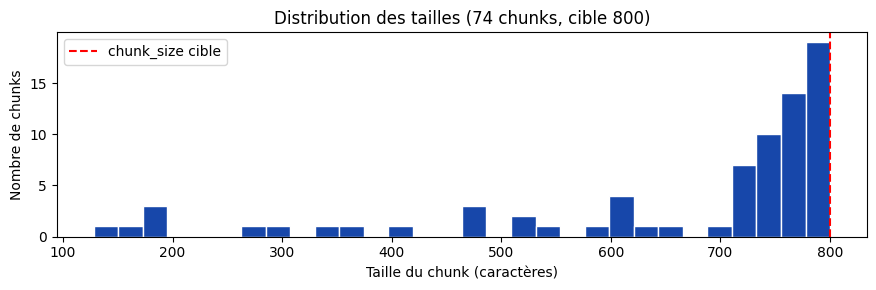

In [6]:
# Distribution des tailles des chunks — utile pour valider notre chunk_size.
import matplotlib.pyplot as plt

sizes = [len(c.page_content) for c in chunks]
plt.figure(figsize=(9, 3))
plt.hist(sizes, bins=30, color="#1747aa", edgecolor="white")
plt.xlabel("Taille du chunk (caractères)")
plt.ylabel("Nombre de chunks")
plt.title(f"Distribution des tailles ({len(chunks)} chunks, cible 800)")
plt.axvline(800, color="red", linestyle="--", label="chunk_size cible")
plt.legend()
plt.tight_layout()
plt.show()

💡 **À noter** : tous les chunks ne font pas exactement 800 caractères — c'est normal. Le splitter privilégie les coupures naturelles (fin de paragraphe, de phrase) sur la taille exacte. C'est *exactement* ce qu'on veut.

---
## 3. Les embeddings

On transforme chaque texte en **vecteur** (liste de nombres réels). Deux textes sémantiquement proches auront des vecteurs proches — c'est ce qui permet la **recherche par similarité**.

On utilise `intfloat/multilingual-e5-base` : modèle HuggingFace, gratuit, multilingue (excellent en français), 768 dimensions. Au premier appel, il est téléchargé (~1 Go) puis mis en cache.

In [7]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="intfloat/multilingual-e5-base",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True},
)
print("✓ Modèle d'embeddings chargé")

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

C:\Users\User\Desktop\Developpement\Formation-RAG\seance2\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub\models--intfloat--multilingual-e5-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


README.md:   0%|          | 0.00/179k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

✓ Modèle d'embeddings chargé


In [8]:
# Embedder une phrase et observer la sortie.
vec = embeddings.embed_query("Qu'est-ce qu'un système RAG ?")

print(f"✓ Dimension du vecteur : {len(vec)}")
print(f"✓ 10 premières valeurs   : {[round(x, 4) for x in vec[:10]]}")
print(f"✓ Norme du vecteur       : {sum(x*x for x in vec) ** 0.5:.4f}")
# Norme = 1.0 car on a activé normalize_embeddings.

✓ Dimension du vecteur : 768
✓ 10 premières valeurs   : [0.0173, 0.0367, -0.0062, 0.0311, 0.0281, -0.0146, -0.0266, -0.0417, 0.0127, 0.0426]
✓ Norme du vecteur       : 1.0000


In [9]:
# Vérifions le pouvoir sémantique des embeddings :
# deux phrases qui veulent dire la même chose doivent être proches,
# une phrase sans rapport doit être loin.
import numpy as np

def cosine(a, b):
    a, b = np.array(a), np.array(b)
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

phrases = [
    "Le RAG combine recherche documentaire et génération.",
    "Un système RAG cherche d'abord puis génère une réponse.",
    "Les bananes sont jaunes et pleines de potassium.",
]

vecs = [embeddings.embed_query(p) for p in phrases]

print(f"Similarité (1 ↔ 2) — sémantiquement proches : {cosine(vecs[0], vecs[1]):.4f}")
print(f"Similarité (1 ↔ 3) — sans rapport          : {cosine(vecs[0], vecs[2]):.4f}")

Similarité (1 ↔ 2) — sémantiquement proches : 0.8875
Similarité (1 ↔ 3) — sans rapport          : 0.8051


💡 **Lecture du résultat** : la similarité entre phrases 1 et 2 doit être nettement supérieure à 1 et 3. C'est cette propriété qui rend possible la recherche sémantique.

---
## 4. Le vector store (Chroma)

On stocke tous nos chunks (vecteurs + texte + métadonnées) dans une **base vectorielle**. Chroma est open-source, simple, et persiste sur disque.

**Attention** : la base est persistée dans `chroma_db/`. Si vous relancez ce notebook plusieurs fois, vous allez **réindexer les mêmes chunks** plusieurs fois. En production, on gère cela avec un système d'identifiants — pour la séance, on suppose une indexation unique.

In [ ]:
from langchain_chroma import Chroma

persist_dir = project_root / "chroma_db"
persist_dir.mkdir(exist_ok=True)

# 🎯 Note formateur : on utilise volontairement un nom de collection DIFFÉRENT
# de celui défini dans rag_pdf/config.py (qui vaut "rag_pdf"). C'est intentionnel
# pour faire surgir un bug en section 9 (cellule finale) — l'occasion d'apprendre
# l'importance de centraliser TOUTE la config en un seul endroit.
vector_store = Chroma(
    collection_name="rag_pdf_notebook",
    embedding_function=embeddings,
    persist_directory=str(persist_dir),
)

# Indexation : Chroma va embedder chaque chunk puis le stocker.
vector_store.add_documents(chunks)

count = vector_store._collection.count()
print(f"✓ {count} chunks indexés dans la collection 'rag_pdf_notebook'")
print(f"✓ Base persistée dans : {persist_dir}")

---
## 5. La recherche par similarité (retrieval brut)

On peut maintenant **chercher** : on donne une question, Chroma trouve les chunks les plus proches dans l'espace des embeddings.

In [11]:
question = "Quelles sont les limites des LLM qui justifient l'utilisation d'un RAG ?"

results = vector_store.similarity_search_with_score(question, k=4)

for i, (doc, score) in enumerate(results, 1):
    page = doc.metadata.get("page", "?")
    extrait = doc.page_content.replace("\n", " ")[:200]
    print(f"--- Résultat {i}  |  Page {page + 1 if isinstance(page, int) else page}  |  score = {score:.4f} ---")
    print(extrait + "...\n")

--- Résultat 1  |  Page 5  |  score = 0.2277 ---
2. Les LLM : capacités et fonctionnement vulgarisé 3. Les limites des LLM : pourquoi le RAG est-il nécessaire ? 4. Positionnement du RAG vs Fine-tuning vs Prompt Engineering 5. Qu’est-ce qu’un RAG ? 6...

--- Résultat 2  |  Page 12  |  score = 0.2623 ---
4.7 Synthèse des limites Limite Conséquence Le RAG aide-t-il ? Hallucinations Information fausse Oui, en ancrant la réponse dans des documents Knowledge cutoff Pas d’actualité Oui, en injectant du con...

--- Résultat 3  |  Page 2  |  score = 0.2701 ---
9 3.3.4 L’architecture Transformer . . . . . . . . . . . . . . . . . . . . . . . . . . 9 3.4 Que savent vraiment faire les LLM ? . . . . . . . . . . . . . . . . . . . . . . . . . 10 4 Les limites des ...

--- Résultat 4  |  Page 5  |  score = 0.2818 ---
1 Introduction et objectifs 1.1 Pourquoi cette formation ? L’intelligence artificielle générative, et en particulier les Large Language Models (LLM) comme GPT-4, Claude ou Llama, ont trans

💡 **Lecture** :
- Chez Chroma, **plus le score est bas, plus le chunk est proche** (c'est une distance, pas une similarité).
- Le numéro de page affiché ici est encore 0-indexé (PyMuPDF natif) ; notre package le normalisera.
- Si les chunks remontés vous semblent pertinents → bon signe, votre RAG sait *trouver*. Reste à le faire *générer*.

---
## 6. Le LLM (Groq)

On va utiliser **Llama 3.3 70B** via l'API Groq. Groq est ultra-rapide (~500 tokens/sec) et gratuit avec des limites raisonnables — parfait pour la formation.

Testons-le d'abord **sans contexte** pour bien observer la différence.

In [12]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.0)

# Question "générique" — le LLM peut y répondre avec ses connaissances générales.
reponse_generique = llm.invoke("En une phrase, qu'est-ce qu'un système RAG ?")
print("=== Réponse sans contexte ===")
print(reponse_generique.content)

=== Réponse sans contexte ===
Un système RAG (Rouge, Ambre, Vert) est un système de gestion des risques et de classification des problèmes ou des situations en trois catégories de gravité ou de priorité, représentées par les couleurs rouge, ambre et vert, afin de faciliter la prise de décision et la gestion des ressources.


In [13]:
# Question pointue sur NOTRE document — le LLM seul ne peut PAS bien répondre.
reponse_pointue = llm.invoke(
    "D'après le cours de Christ Nzonde, combien de limites majeures des LLM sont identifiées "
    "et quelles sont-elles précisément ?"
)
print("=== Réponse sans contexte (question pointue) ===")
print(reponse_pointue.content)

=== Réponse sans contexte (question pointue) ===
D'après le cours de Christ Nzonde, il est mentionné que les LLM (Large Language Models) ont plusieurs limites majeures. Voici les limites identifiées :

1. **Manque de compréhension profonde** : Les LLM sont capables de traiter et de générer du texte, mais ils ne comprennent pas réellement le sens et le contexte du texte. Ils se basent sur des modèles statistiques pour prédire les mots suivants dans une phrase, mais ils ne possèdent pas une compréhension profonde du langage.

2. **Dépendance aux données d'entraînement** : Les LLM sont entraînés sur des grandes quantités de données textuelles, mais ces données peuvent être biaisées, incomplètes ou obsolètes. Cela peut entraîner des résultats inexacts ou biaisés.

3. **Manque de contextualisation** : Les LLM ont du mal à comprendre le contexte dans lequel le texte est utilisé. Ils peuvent ne pas prendre en compte les nuances du langage, les références culturelles ou les informations implic

💡 **Observez** : sur la question pointue, le LLM va probablement inventer ou rester vague — il n'a **jamais lu notre PDF**. C'est précisément le rôle du RAG : lui *fournir* les bons passages.

---
## 7. La chaîne RAG complète (LCEL)

On assemble maintenant **tout le pipeline** avec LangChain Expression Language (LCEL, l'opérateur `|`).

Le prompt système est conçu pour :
1. **Restreindre** la réponse au contexte fourni (anti-hallucination)
2. **Autoriser** l'aveu d'ignorance ("Je n'ai pas trouvé…")
3. **Forcer** la citation des pages `[Page X]`

In [14]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableLambda, RunnablePassthrough

RAG_SYSTEM = """Tu es un assistant pédagogique qui répond aux questions \
en t'appuyant UNIQUEMENT sur le contexte fourni ci-dessous.

Règles strictes :
1. Si la réponse n'est pas dans le contexte, dis : « Je n'ai pas trouvé cette information dans le document. »
2. N'invente JAMAIS d'information.
3. Cite les pages sources : [Page X].
4. Réponds en français, clair et concis.

CONTEXTE :
{context}
"""

prompt = ChatPromptTemplate.from_messages([
    ("system", RAG_SYSTEM),
    ("human", "QUESTION : {question}"),
])


def format_context(docs):
    """Assemble les chunks récupérés en un bloc de contexte avec balises de page."""
    parts = []
    for d in docs:
        # PyMuPDF natif renvoie une page 0-indexée — on l'affiche en 1-indexée pour l'humain.
        page = d.metadata.get("page", 0) + 1
        parts.append(f"[Page {page}]\n{d.page_content}")
    return "\n\n---\n\n".join(parts)


retriever = vector_store.as_retriever(search_kwargs={"k": 4})

# Chaîne LCEL : question -> (retrieve + format + question) -> prompt -> LLM -> texte
rag_chain = (
    {
        "context": retriever | RunnableLambda(format_context),
        "question": RunnablePassthrough(),
    }
    | prompt
    | llm
    | StrOutputParser()
)
print("✓ Chaîne RAG assemblée")

✓ Chaîne RAG assemblée


In [15]:
question = "Quelles sont les 6 limites majeures des LLM identifiées dans le cours ?"
reponse = rag_chain.invoke(question)

print("=== QUESTION ===")
print(question)
print("\n=== RÉPONSE ===")
print(reponse)

=== QUESTION ===
Quelles sont les 6 limites majeures des LLM identifiées dans le cours ?

=== RÉPONSE ===
Les 6 limites majeures des LLM identifiées dans le cours sont :

1. Les hallucinations (Limite n°1) [Page 10]
2. Le knowledge cutoff (Limite n°2) [Page 11]
3. Pas d'accès aux données privées (Limite n°3) [Page 11]
4. Absence de sources et de traçabilité (Limite n°4) [Page 11]
5. La fenêtre de contexte (Limite n°5) [Page 11]
6. Le coût du fine-tuning (Limite n°6) [Page 11]

Ces limites sont présentées dans les sections 4.1 à 4.6 [Page 10-11].


🎉 **Notre Naive RAG fonctionne !** 

Observez bien : la réponse cite des `[Page X]`, et ces pages correspondent vraiment au passage où l'info se trouve dans le cours. Pas d'hallucination, traçabilité totale.

---
## 8. Quelques tests libres — identifier les limites du Naive RAG

Avant de refactorer, posons quelques questions variées et observons ce qui marche bien… et ce qui marche moins bien. **Ce sera notre point de départ pour la séance 3.**

In [16]:
questions_test = [
    # Questions "directes" — le RAG devrait bien s'en sortir.
    "Qu'est-ce qu'un embedding ?",
    "Quels sont les différents types de RAG mentionnés ?",
    # Question avec une formulation "vague" — sensibilité du retrieval.
    "Comment ça marche au fait, ce truc ?",
    # Question hors-document — le LLM doit refuser.
    "Quelle est la capitale de l'Australie ?",
    # Question qui demande de croiser plusieurs sections.
    "Quelle est la différence entre le fine-tuning et le RAG, et quand préférer chacun ?",
]

for q in questions_test:
    print("━" * 80)
    print(f"❓ {q}")
    print("━" * 80)
    print(rag_chain.invoke(q))
    print()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
❓ Qu'est-ce qu'un embedding ?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Un embedding est une représentation vectorielle (une liste de nombres réels) d’un mot, d’une phrase ou d’un document. Des contenus sémantiquement proches ont des vecteurs proches dans cet espace [Page 9]. C'est-à-dire que les embeddings permettent de représenter des mots ou des phrases de manière à ce que ceux qui sont sémantiquement proches soient également proches dans l'espace vectoriel. 

De plus, le glossaire à la page 28 définit l'embedding comme un "Vecteur numérique représentant le sens d’un texte" [Page 28].

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
❓ Quels sont les différents types de RAG mentionnés ?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Selon le contexte fourni, les différents types de RAG mentionnés son

💡 **Notez vos observations** :
- Quelles questions ont reçu une bonne réponse ?
- Sur la question vague ("ce truc"), le retrieval a-t-il trouvé les bons chunks ?
- Le LLM a-t-il bien refusé la question hors-document ?

Ces observations motiveront les optimisations de la séance 3 :
- **Reformulation de question** (pour rendre les questions vagues exploitables)
- **Re-ranker** (pour mieux ordonner les chunks récupérés)
- **Évaluation systématique** avec RAGAS

In [ ]:
# Bonus : le streaming token par token — pour voir la réponse arriver en temps réel.
for chunk in rag.stream("Qu'est-ce que le RAG ?"):
    print(chunk, end="", flush=True)  # ← le texte arrive token par token

---
## 9. Refactor : du notebook au package professionnel

Tout le code que nous venons d'écrire a été **organisé en modules** dans `src/rag_pdf/` :

| Ce qu'on a fait dans le notebook | Où c'est dans le package |
|---|---|
| `PyMuPDFLoader` + normalisation page | `rag_pdf/ingestion/loader.py` |
| `RecursiveCharacterTextSplitter` | `rag_pdf/ingestion/splitter.py` |
| `HuggingFaceEmbeddings` | `rag_pdf/indexing/embedder.py` |
| `Chroma` + persistance | `rag_pdf/indexing/vector_store.py` |
| `similarity_search` | `rag_pdf/retrieval/retriever.py` |
| `ChatGroq` | `rag_pdf/generation/llm.py` |
| Le prompt système | `rag_pdf/generation/prompts.py` |
| L'assemblage LCEL | `rag_pdf/pipeline/rag_chain.py` |
| Tous les paramètres | `rag_pdf/config.py` |

**Résultat** : on peut maintenant construire et utiliser un RAG complet en **3 lignes** depuis n'importe quel script, notebook, ou app web.

In [5]:
# Démonstration — utilisation du package professionnel.
from rag_pdf.pipeline import build_rag_chain

rag = build_rag_chain()

# Sanity-check : la collection ciblée par le package doit contenir des chunks.
# 🎯 ATTENTION : si ce check échoue, c'est probablement le bug pédagogique de la
# section 4. Notre `build_rag_chain()` lit le nom de collection depuis
# rag_pdf/config.py (= "rag_pdf"), mais le notebook a indexé dans
# "rag_pdf_notebook". Deux solutions :
#   (a) Aligner le notebook sur la config → cellule de la section 4,
#       remplacer collection_name="rag_pdf_notebook" par "rag_pdf"
#   (b) Re-ingérer via le CLI :
#       uv run python -m scripts.ingest data/pdfs/cours_rag_theorie.pdf
# C'est exactement pour ça qu'on centralise TOUT dans config.py en projet pro.
n = rag.retriever.vector_store.count()
assert n > 0, (
    "❌ La collection 'rag_pdf' (celle du package) est vide. "
    "Voir le commentaire ci-dessus pour les deux solutions possibles."
)
print(f"✓ Collection 'rag_pdf' contient {n} chunks\n")

answer = rag.invoke("Quels sont les composants techniques d'un RAG ?")

print("=== RÉPONSE ===")
print(answer.answer)
print(f"\n=== SOURCES ===")
print(f"Pages citées : {answer.unique_pages}")
for src in answer.sources:
    print(f"\n[Page {src.page}] {src.content[:150]}...")

[06/01/26 03:12:55] INFO     Chargement du modèle d'embeddings : intfloat/multilingual-e5-base

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[06/01/26 03:13:07] INFO     Initialisation du LLM Groq : llama-3.3-70b-versatile

✓ Collection 'rag_pdf' contient 74 chunks



[06/01/26 03:13:07] INFO     Question : Quels sont les composants techniques d'un RAG ?

[06/01/26 03:13:08] INFO     → 7 chunks récupérés (pages : [0, 1, 2, 4, 14, 17, 19])

=== RÉPONSE ===
Les composants techniques d'un RAG incluent les document loaders, les text splitters/chunkers [Page 17]. Les document loaders sont des outils qui extraient le texte et parfois la structure depuis des fichiers ou des APIs, tels que PyPDF, PDFPlumber, Unstructured, PyMuPDF pour les PDF, BeautifulSoup, Scrapy, Playwright pour le web, python-docx, openpyxl pour les documents Office, connecteurs Notion, Confluence, Slack, GitHub, Google Drive pour les APIs, Whisper pour la transcription audio, et OCR (Tesseract, AWS Textract, GPT-4 Vision) pour les images et les scans [Page 17]. 

Les text splitters/chunkers sont utilisés pour découper le texte en chunks, avec différentes stratégies telles que fixed-size, recursive, markdown-aware et code-aware [Page 17]. 

Ces composants sont essentiels pour le fonctionnement d'un système RAG, qui implique également d'autres étapes comme l'indexation et le retrieval [Page 14].

=== SOURCES ===
Pages citées : [0, 1, 2, 4, 14, 17, 19]

[Page 

💡 **À retenir** :
- Le notebook nous a permis d'**explorer** et de **comprendre** chaque brique.
- Le package nous donne une **API stable** et réutilisable.
- L'app Streamlit de la séance 3 utilisera **exactement la même API** (`build_rag_chain()` + `rag.invoke(question)`).

In [7]:
# Bonus : le streaming token par token — pour voir la réponse arriver en temps réel.
for chunk in rag.stream("Qu'est-ce que le RAG et comment il fonctionne de manière détaillé ?"):
    print(chunk, end="", flush=True)  # ← le texte arrive token par token

[06/01/26 03:13:48] INFO     Question (stream) : Qu'est-ce que le RAG et comment il fonctionne de manière détaillé 
                             ?

                    INFO     → 7 chunks récupérés (pages : [1, 4, 13, 14, 19])

Un système RAG (Retrieval-Augmented Generation) est une architecture qui, face à une question utilisateur, recherche dans une base de documents les passages les plus pertinents, construit un prompt augmenté contenant ces passages, puis demande à un LLM (Large Language Model) de produire la réponse en s'appuyant explicitement sur ce contexte [Page 13].

Le fonctionnement détaillé d'un RAG se décompose en deux phases bien distinctes : une phase d'indexation (hors-ligne, préparatoire) et une phase de retrieval + génération (en ligne, à chaque question) [Page 14].

La phase d'indexation (offline) prépare la base de connaissances en chargant les documents, en les découpant en chunks, en créant des embeddings, puis en stockant ces embeddings dans un vector store [Page 14]. 

La phase de retrieval + génération (en ligne) commence par la recherche des passages les plus pertinents dans la base de documents, suivie de la construction d'un prompt augmenté contenant ces passages, puis de la généra

---
## 10. Workflow CLI (sans notebook)

Le même pipeline est utilisable en ligne de commande :

```powershell
# Indexer un PDF
uv run python -m scripts.ingest data/pdfs/cours_rag_theorie.pdf

# Lancer le RAG en mode interactif
uv run python -m scripts.query
```

C'est la base de toute application : une **API publique** (`build_rag_chain`) qu'on peut appeler depuis un notebook, un script, une CLI, ou une app web — sans dupliquer le code métier.

---

## Récapitulatif de la séance

Nous avons construit un RAG complet en explorant chaque brique :

✅ Chargement de PDF avec préservation des numéros de page  
✅ Découpage en chunks avec stratégie récursive  
✅ Embeddings multilingues HuggingFace  
✅ Vector store Chroma persistant  
✅ Retrieval par similarité  
✅ Prompt système anti-hallucination avec citations  
✅ Génération avec Llama 3.3 via Groq  
✅ Pipeline LCEL complet  
✅ Refactor en package professionnel modulaire  

## En séance 3, nous allons

🔜 **Construire un golden dataset** pour évaluer notre RAG objectivement  
🔜 **Mesurer avec RAGAS** : faithfulness, answer relevancy, context precision/recall  
🔜 **Ajouter la reformulation de question** (pré-retrieval) et **un reranker** (post-retrieval)  
🔜 **Comparer 4 configurations** A/B/C/D et chiffrer l'apport de chaque technique  
🔜 **Construire une app web Streamlit** qui affiche les pages PDF sources  

---
## 11. Bonus — Le streaming token par token

Au lieu d'attendre que le LLM finisse de générer toute la réponse, on peut afficher les tokens **au fur et à mesure** qu'ils arrivent. C'est ce que fait ChatGPT dans son UI — beaucoup plus agréable que de regarder un spinner pendant 5 secondes.

La méthode `.stream()` de `RAGChain` (voir `src/rag_pdf/pipeline/rag_chain.py`) yield des chunks de texte un par un. Les sources sont accessibles **après** le stream via `rag.last_sources`.

> ⚠️ **Piège classique de Jupyter** : si tu viens de modifier un fichier du package (par ex. ajouter une méthode `.stream()` dans `rag_chain.py`), Jupyter ne le voit **pas automatiquement**. Deux solutions :
> 1. **Restart Kernel** + ré-exécuter les cellules nécessaires (le plus sûr).
> 2. Activer **autoreload** dans la cellule ci-dessous (à mettre une seule fois en haut du notebook idéalement).

In [ ]:
# Active le rechargement automatique des modules Python.
# À partir de maintenant, toute modif dans src/rag_pdf/ est prise en compte immédiatement.
%load_ext autoreload
%autoreload 2

# Import (ou ré-import) du package — autoreload fera le reste à chaque changement.
from rag_pdf.pipeline import build_rag_chain

rag = build_rag_chain()
print("✓ RAG prêt avec autoreload activé")

In [ ]:
# Streaming en action — la réponse s'affiche token par token.
question = "Quels sont les différents types de RAG mentionnés dans le cours ?"

print(f"❓ {question}\n")
print("─" * 70)
print("Réponse (en streaming) :\n")

for chunk in rag.stream(question):
    print(chunk, end="", flush=True)

print("\n" + "─" * 70)

# Les sources sont disponibles APRÈS le stream :
pages = sorted({src.page for src in rag.last_sources})
print(f"\n📄 Sources consultées : pages {pages}")